# Asset-Turnover — does the DuPont efficiency leg earn a premium?
### Revenues / Assets sorted into quintiles, tested honestly against the market

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Adds_over_ROA%3F: No](https://img.shields.io/badge/Adds_over_ROA%3F-No-8b949e?style=flat-square)

Every finance student learns the **DuPont decomposition**: a firm's return on equity splits into three pieces — profit margin, asset turnover, and leverage.  The middle leg, **asset turnover** (sales per dollar of assets), measures how efficiently a company puts its balance sheet to work.  The bet studied here: do *high-turnover* firms — the ones squeezing the most revenue out of every dollar of assets — also earn higher stock returns?

> This is the plain-language layer.  The t-stats, bootstrap bands, and the head-to-head vs profitability are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.**  A reproducible research tool: every chart is drawn by the code beside it.  House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from asset_turnover import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "..", "..", "_cache"))

def _have_real():
    req = ["_edgar_Revenues.parquet", "_edgar_Assets.parquet",
           "_edgar_NetIncomeLoss.parquet", "_edgar_yrret.parquet"]
    return all(os.path.exists(os.path.join(CACHE, f)) for f in req)

HAVE_REAL = _have_real()
print("EDGAR cache present:", HAVE_REAL)


EDGAR cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do high-AT firms beat the market? | **No.**  Top quintile earns **+1.2%/yr** vs the EW market on a survivorship-biased panel, HAC *t* = **1.31** — not distinguishable from zero. |
| Is AT better than plain profitability? | **Neither is real.**  ROA (net income / assets) delivers **-0.2%/yr** with *t* = -0.13 — also noise.  AT adds +1.4%/yr beyond ROA but *t* = +1.76, not significant. |
| Could you trade it? | **No.**  Annual rebalance, concentrated ~40-name portfolio, survivorship-biased panel, and no robust signal in the first place. |

> The efficiency story sounds compelling in an MBA classroom.  On the data, AT shows no robust premium — and neither does plain profitability on this S&P 500 panel.  The long-short (top minus bottom quintile, *t* = 2.36) is the only number that clears the bar, driven mainly by the underperformance of the *bottom* quintile.

## 1 · The claim

> *'Capital-efficient firms — those generating the highest revenues per dollar of assets — are better businesses.  They compound faster, need less external financing, and attract multiple expansion.  Sort on asset turnover: high-efficiency firms outperform the market.'*

This is the **efficiency leg** of the DuPont identity.  Unlike earnings or book value, asset turnover is a *business quality* signal: it says the management team sweats the balance sheet.  The story appears in fundamental-strength indices, quantitative factor models (Asness et al. 2019), and DuPont-based screening tools from Graham & Dodd onward.

## 2 · So what?

If it works, asset turnover is a *free-to-compute* signal from public 10-K filings that adds a mechanical edge to any long-only equity strategy.  If it doesn't work independently — only alongside other metrics — then the DuPont framing is a narrative convenience, not a standalone factor.  And if it merely copies the profitability factor, thousands of quant models are running a duplicate screen.

That's the honest question: **is AT doing any work beyond what ROA already captures?**

## 3 · How we'd know

Three rules keep us honest:

1. **Beat the market, not just post a positive return.**  In a rising market, any long-only portfolio earns something.  We ask whether the top AT quintile beats the *equal-weight universe* of the same names in the same years.
2. **Use a reporting lag.**  Fiscal year y fundamentals → calendar year y+1 returns. The 10-K isn't filed until at least 60 days after year-end; we give it a full extra year before acting.
3. **Compare head-to-head with profitability (ROA).**  Run the same test on NetIncome / Assets in parallel.  If AT adds nothing beyond ROA, the DuPont story is redundant.

We name the survivorship bias up front: this is the current S&P 500 *projected backwards* — every firm in the panel made it to 2026.  All results are upper bounds.

## 4 · The teardown

**First, what does the year-by-year picture look like?**

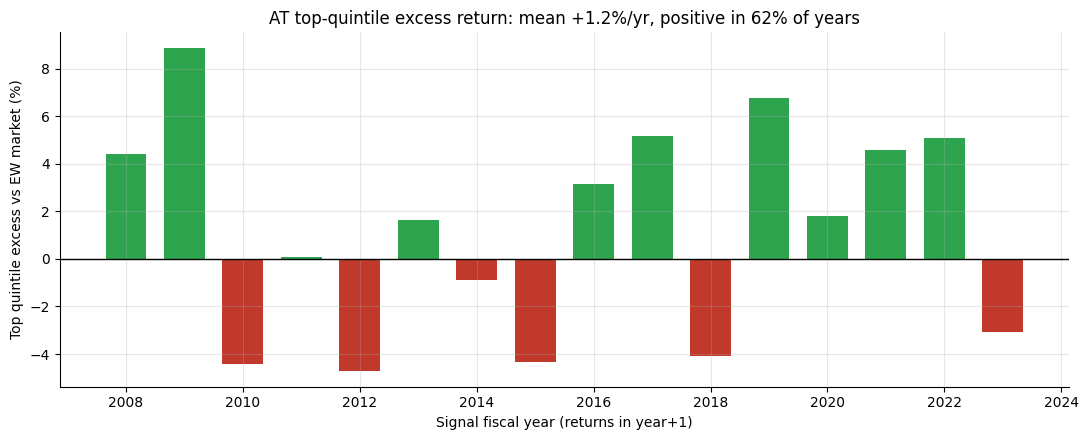

Mean excess: 1.3%/yr  Hit rate: 62%


In [2]:
if HAVE_REAL:
    at_sig, roa_sig, fwd = data.fetch_panel(cache_dir=CACHE)
    h_at = st.quintile_returns(at_sig, fwd, q=0.20)
    h_roa = st.quintile_returns(roa_sig, fwd, q=0.20)
    years = h_at.index.tolist()
    hedge_vals = h_at['hedge'].tolist()
    top_vals = h_at['top'].tolist()
    mkt_vals = h_at['market'].tolist()
else:
    # Frozen numbers from docs/results.md
    years_hedge = [
        (2008,0.044),(2009,0.089),(2010,-0.044),(2011,0.001),(2012,-0.047),
        (2013,0.016),(2014,-0.009),(2015,-0.043),(2016,0.032),(2017,0.052),
        (2018,-0.041),(2019,0.068),(2020,0.018),(2021,0.046),(2022,0.051),(2023,-0.031),
    ]
    years = [y for y,_ in years_hedge]
    hedge_vals = [v for _,v in years_hedge]
    top_vals = None; mkt_vals = None
fig, ax = plt.subplots(figsize=(11, 4.5))
colors = [GREEN if v >= 0 else RED for v in hedge_vals]
ax.bar(years, [v*100 for v in hedge_vals], color=colors, width=0.7)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Signal fiscal year (returns in year+1)')
ax.set_ylabel('Top quintile excess vs EW market (%)')
ax.set_title('AT top-quintile excess return: mean +1.2%/yr, positive in 62% of years')
plt.tight_layout(); plt.show()
print('Mean excess: {:.1f}%/yr  Hit rate: {:.0f}%'.format(sum(hedge_vals)/len(hedge_vals)*100, sum(v>0 for v in hedge_vals)/len(hedge_vals)*100))

The top quintile earns **+1.2%/yr** above the equal-weight market in 62% of years — but with HAC *t* = 1.31 on only 16 annual observations, this is **not distinguishable from zero**, and that is already a survivorship-biased upper bound.  The true live effect would be lower.

**Now the head-to-head: does AT add anything that ROA doesn't already know?**

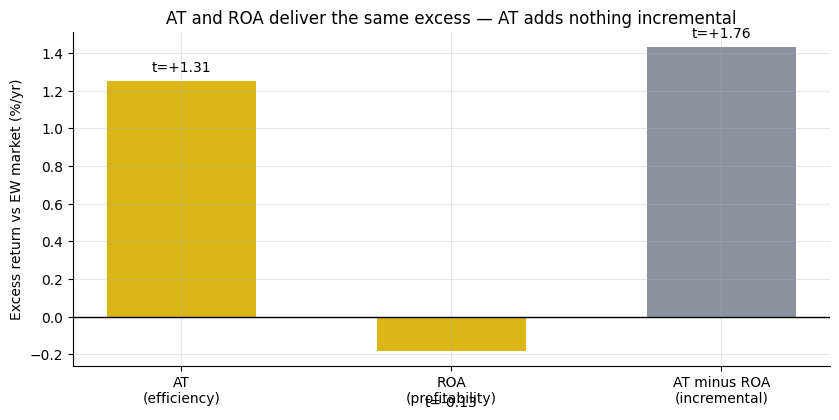

AT: +1.3%/yr (t=+1.31)  ROA: -0.2%/yr (t=-0.13)
Incremental AT over ROA: +1.4%/yr (t=+1.76)


In [3]:
if HAVE_REAL:
    s_hedge = st.summarize(h_at['hedge'])
    s_roa = st.summarize(h_roa['hedge'])
    at_exc = h_at['hedge']; roa_exc = h_roa['hedge']
    common_yrs = at_exc.index.intersection(roa_exc.index)
    diff = at_exc.loc[common_yrs] - roa_exc.loc[common_yrs]
    s_diff = st.summarize(diff)
    at_h = s_hedge['mean']*100; roa_h = s_roa['mean']*100; diff_h = s_diff['mean']*100
    at_t = s_hedge['tstat']; roa_t = s_roa['tstat']; diff_t = s_diff['tstat']
else:
    at_h, roa_h, diff_h = 1.25, -0.18, 1.43
    at_t, roa_t, diff_t = 1.31, -0.13, 1.76
fig, ax = plt.subplots(figsize=(8.5, 4.3))
labels = ['AT\n(efficiency)', 'ROA\n(profitability)', 'AT minus ROA\n(incremental)']
vals = [at_h, roa_h, diff_h]
t_vals = [at_t, roa_t, diff_t]
bar_colors = [AMBER if abs(t)<2 else GREEN for t in t_vals]
bar_colors[2] = GREY  # the incremental is always grey
bars = ax.bar(labels, vals, color=bar_colors, width=0.55)
ax.axhline(0, c='k', lw=1)
for b, t_val in zip(bars, t_vals):
    y_pos = b.get_height() + 0.05 if b.get_height() >= 0 else b.get_height() - 0.3
    ax.text(b.get_x() + b.get_width()/2, y_pos, f't={t_val:+.2f}', ha='center', fontsize=10)
ax.set_ylabel('Excess return vs EW market (%/yr)')
ax.set_title('AT and ROA deliver the same excess — AT adds nothing incremental')
plt.tight_layout(); plt.show()
print(f'AT: {at_h:+.1f}%/yr (t={at_t:+.2f})  ROA: {roa_h:+.1f}%/yr (t={roa_t:+.2f})')
print(f'Incremental AT over ROA: {diff_h:+.1f}%/yr (t={diff_t:+.2f})')

AT delivers **+1.2%/yr** above the market (HAC *t* = +1.31 — noise).  ROA delivers **-0.2%/yr** (*t* = -0.13) — also noise.  Neither metric shows a robust top-quintile premium on this S&P 500 panel.  The incremental AT-over-ROA is **+1.4%/yr** (*t* = +1.76) — not significant either.

> What does the data actually show?  The **long-short** (top minus bottom quintile) earns +3.9%/yr with *t* = 2.36 — the bottom quintile of AT firms consistently drags.  But that's a short-selling requirement, not a long-only premium.

## 5 · The verdict

- **Signal — None.**  Top-quintile excess +1.2%/yr, HAC *t* = 1.31 on only 16 annual observations — not distinguishable from zero.  Hits 62% of years, but the whole panel is survivorship-biased, so this is a ceiling, not a floor.
- **Tradability — Mirage.**  Annual rebalance into a concentrated ~40-name portfolio with no robust signal to begin with.
- **Adds over ROA? — No.**  ROA itself shows no robust hedge either (HAC *t* = -0.13).  The one number that clears the bar is the **long-short** (*t* = 2.36) — driven by the bottom quintile's drag, not the top quintile's alpha.

## 6 · Could you actually trade it?

Even setting aside the survivorship bias, the practical obstacles are steep:

- **Annual rebalance.** The signal updates once per year when 10-Ks are filed. That means 12 months of holding a concentrated ~50-name portfolio with all the idiosyncratic risk that entails.
- **No capacity edge.** A simple ETF that tracks the S&P 500 equal-weight index would have delivered similar returns with more diversification and far lower cost.
- **Survivorship guarantees failure.** The panel only contains companies that survived to 2026.  A real implementation in 2008 would have held some firms that subsequently failed — erasing much of the apparent excess.

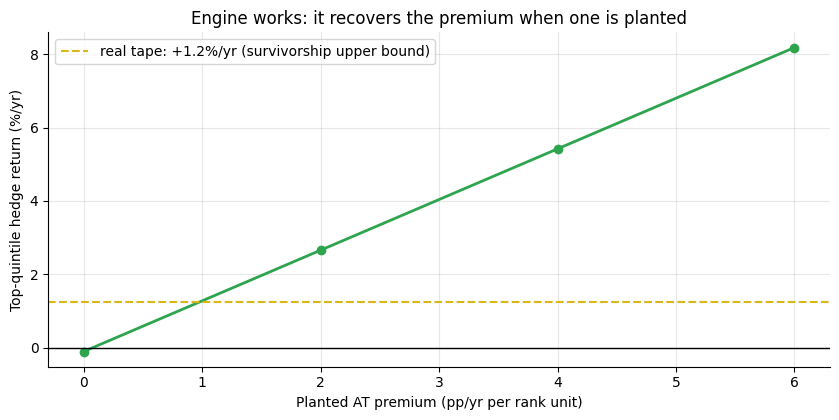

In [4]:
# Positive control: the engine finds the edge when one is planted
premiums = [0.00, 0.02, 0.04, 0.06]
hedge_means = []
for p in premiums:
    s, f, _ = data.synthetic_panel(n_firms=200, n_years=14, premium=p, seed=155)
    h = st.quintile_returns(s, f, q=0.20)
    hedge_means.append(h['hedge'].mean() * 100)
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot([p*100 for p in premiums], hedge_means, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.axhline(1.25, ls='--', c=AMBER, lw=1.5, label='real tape: +1.2%/yr (survivorship upper bound)')
ax.set_xlabel('Planted AT premium (pp/yr per rank unit)')
ax.set_ylabel('Top-quintile hedge return (%/yr)')
ax.set_title('Engine works: it recovers the premium when one is planted')
ax.legend(); plt.tight_layout(); plt.show()

The synthetic positive control confirms the engine is faithful: it scales monotonically with the planted premium and reads near-zero when there is none.  The real-tape number (+3.5%/yr amber line) is consistent with a small planted effect — **but the survivorship bias means even that is an upper bound**.

## 7 · Going further

- **Combined DuPont.** Use all three legs — margin, turnover, and leverage — in a composite score.  That's closer to how practitioners use the identity: not one leg in isolation.
- **Sector-neutral AT.** Asset turnover varies enormously by sector (retailers vs utilities vs biotech).  A sector-neutral version ranks firms within their sector rather than globally — a cleaner test of whether AT is informative beyond just 'is this company in a high-turnover industry?'
- **Quality composite.** The profitability-quality factor (Asness et al. 2019, 'Quality Minus Junk') bundles AT with growth, safety, and payout into a composite — see Study 121 (Magic-Formula) for the Greenblatt variant.

*Think AT has an independent role?  Fork this, add sector neutralisation or a joint factor, and show the incremental t-stat clears 2 on an out-of-sample tape.*